In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Cấu hình giao diện biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc dữ liệu
df = pd.read_csv('../../data/processed/world_bank_macro_yearly.csv')

# TẠO BIẾN TRỄ (LAG ANALYSIS)
# Tạo FDI trễ 1 năm và 2 năm
df['fdi_lag_1'] = df['fdi_percent_gdp'].shift(1)
df['fdi_lag_2'] = df['fdi_percent_gdp'].shift(2)

df

,year,exports_percent_gdp,fdi_percent_gdp,gdp_growth,inflation_cpi,labor_force,unemployment,fdi_lag_1,fdi_lag_2
0,2000,53.921497,4.163924,6.787316,-1.710337,38790735,2.260,NaN,NaN
1,2001,55.061933,3.977335,6.192893,-0.431545,40511879,2.760,4.163924,NaN
2,2002,54.739134,3.992687,6.320821,3.830828,41102232,2.120,3.977335,4.163924
3,2003,56.673258,3.666012,6.899063,3.234648,41746162,2.250,3.992687,3.977335
4,2004,59.731041,3.544081,7.536411,7.754947,42508994,2.140,3.666012,3.992687
5,2005,63.699493,3.390404,7.547248,8.284572,43513617,2.078,3.544081,3.666012
6,2006,67.716814,3.616001,6.977955,7.418017,44781401,2.046,3.390404,3.544081
7,2007,70.517875,8.654718,7.129504,8.344449,46296491,2.026,3.616001,3.390404
8,2008,70.336692,9.663039,5.661771,23.115448,47894666,1.889,8.654718,3.616001
9,2009,62.608884,7.168820,5.397898,6.716983,49267257,1.737,9.663039,8.654718


### Phần 1: EDA - Phân tích xu hướng (Trend Analysis) & Tác động COVID-19

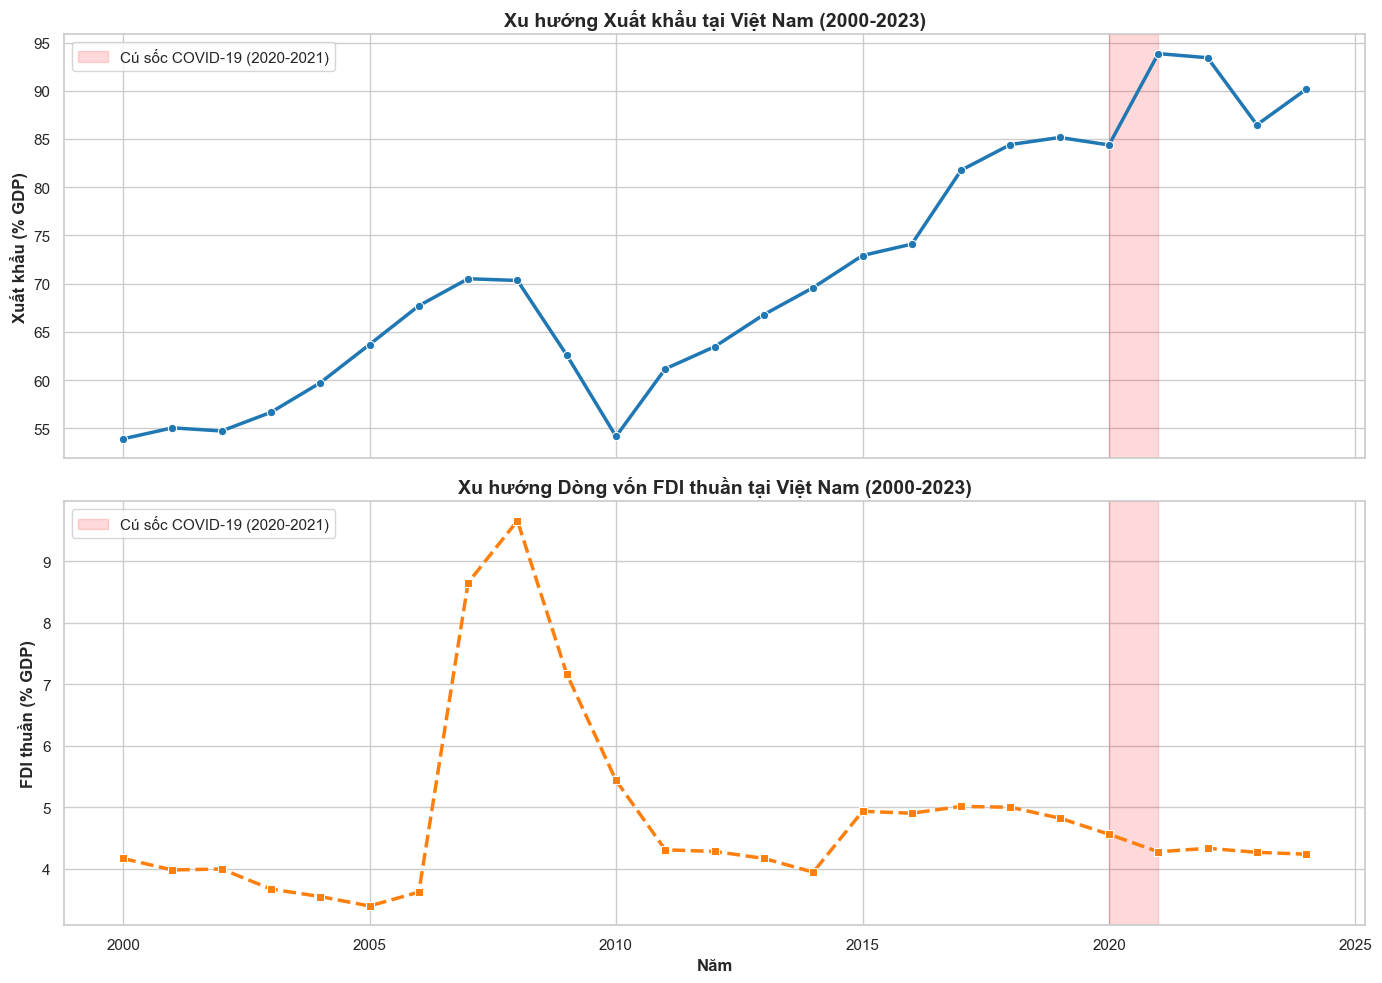

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# BIỂU ĐỒ 1: XUẤT KHẨU
# 
sns.lineplot(data=df, x='year', y='exports_percent_gdp', color='tab:blue', 
             ax=axes[0], marker='o', linewidth=2.5)

axes[0].set_title('Xu hướng Xuất khẩu tại Việt Nam (2000-2023)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Xuất khẩu (% GDP)', fontweight='bold')
axes[0].axvspan(2020, 2021, color='red', alpha=0.15, label='Cú sốc COVID-19 (2020-2021)')
axes[0].legend(loc='upper left')

# BIỂU ĐỒ 2: FDI THUẦN
sns.lineplot(data=df, x='year', y='fdi_percent_gdp', color='tab:orange', 
             ax=axes[1], marker='s', linewidth=2.5, linestyle='--')

axes[1].set_title('Xu hướng Dòng vốn FDI thuần tại Việt Nam (2000-2023)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('FDI thuần (% GDP)', fontweight='bold')
axes[1].set_xlabel('Năm', fontweight='bold')
axes[1].axvspan(2020, 2021, color='red', alpha=0.15, label='Cú sốc COVID-19 (2020-2021)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

Nhìn vào biểu đồ, ta thấy bức tranh của một nền kinh tế có độ mở ngày càng lớn. Tỷ trọng xuất khẩu trên GDP (đường màu xanh) liên tục leo dốc mạnh mẽ, đặc biệt là giai đoạn sau khi Việt Nam gia nhập WTO (2007) và ký kết các Hiệp định thương mại tự do (FTA). Dòng vốn FDI (đường nét đứt màu cam) duy trì ổn định ở mức 4-6% GDP, đóng vai trò là "nhiên liệu" bơm vào cỗ máy xuất khẩu.

Điểm nhấn COVID-19 (Vùng màu đỏ): Giai đoạn 2020-2021 đánh dấu một cú sốc đứt gãy. Dòng vốn FDI đột ngột sụt giảm (do chuyên gia không thể nhập cảnh và nhà đầu tư chần chừ do lệnh phong tỏa). Trong khi đó, xuất khẩu có nhịp chững lại và biến động mạnh do đứt gãy chuỗi cung ứng toàn cầu, các cảng biển đóng cửa và các nhà máy phải thực hiện "3 tại chỗ

### Phần 2: Phân tích Tương quan & Scatter Plots (Exports/FDI ↔ Unemployment)

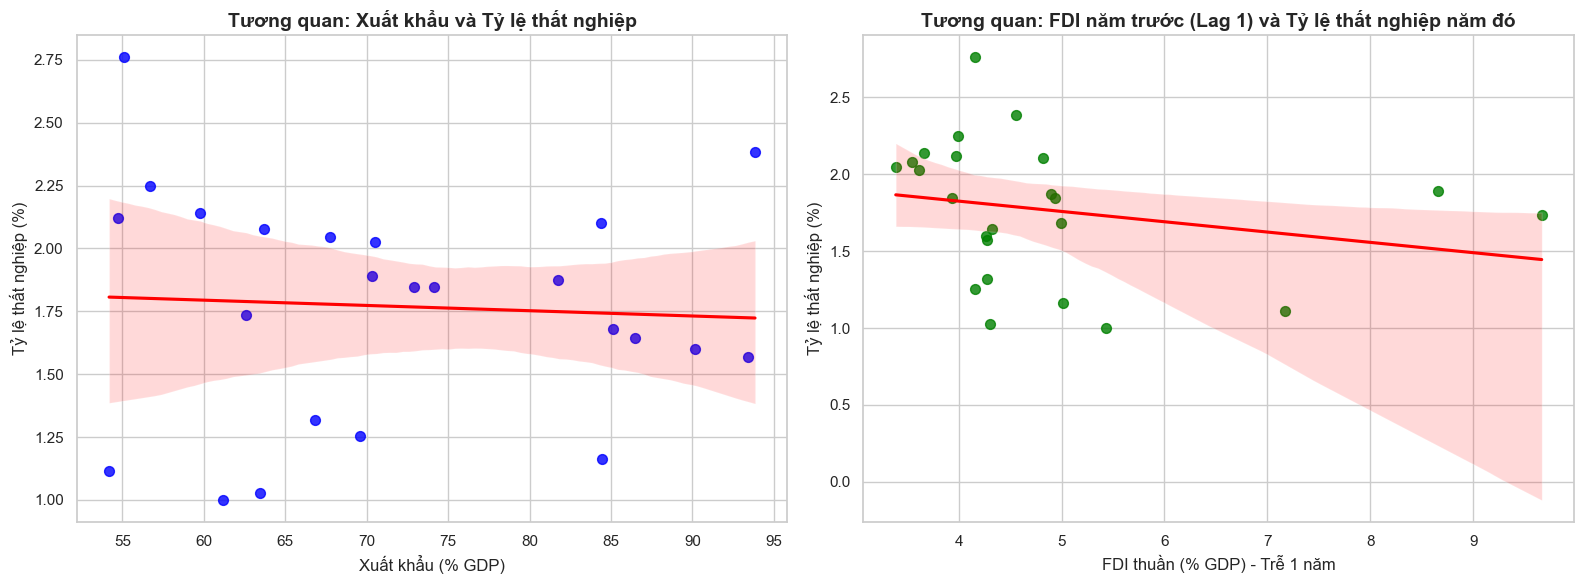

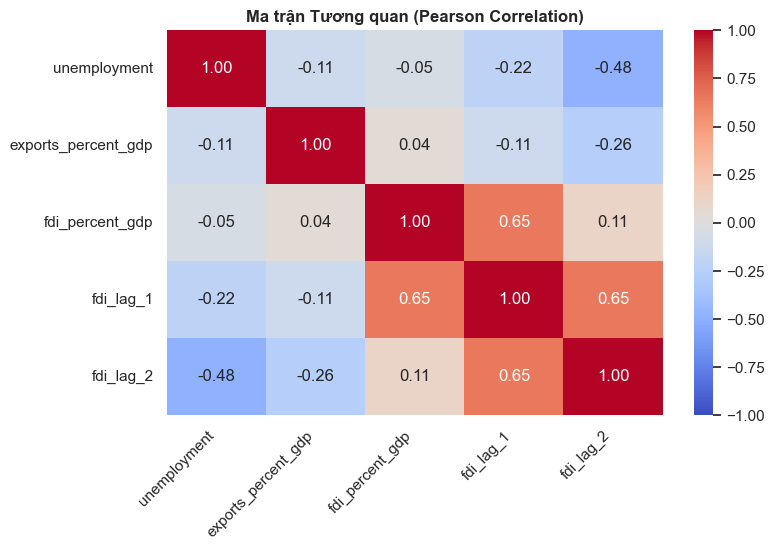

In [15]:
# Lọc bỏ các dòng có NaN để tính toán chính xác
df_clean = df.dropna(subset=['exports_percent_gdp', 'fdi_lag_1', 'unemployment'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Xuất khẩu vs Thất nghiệp
sns.regplot(data=df_clean, x='exports_percent_gdp', y='unemployment', ax=axes[0], 
            color='blue', scatter_kws={'s': 50}, line_kws={'color': 'red'})
axes[0].set_title('Tương quan: Xuất khẩu và Tỷ lệ thất nghiệp', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Xuất khẩu (% GDP)')
axes[0].set_ylabel('Tỷ lệ thất nghiệp (%)')

# Scatter plot: FDI (Trễ 1 năm) vs Thất nghiệp
sns.regplot(data=df_clean, x='fdi_lag_1', y='unemployment', ax=axes[1], 
            color='green', scatter_kws={'s': 50}, line_kws={'color': 'red'})
axes[1].set_title('Tương quan: FDI năm trước (Lag 1) và Tỷ lệ thất nghiệp năm đó', fontsize=14, fontweight='bold')
axes[1].set_xlabel('FDI thuần (% GDP) - Trễ 1 năm')
axes[1].set_ylabel('Tỷ lệ thất nghiệp (%)')

plt.tight_layout()
plt.show()

# Ma trận tương quan
corr_cols = ['unemployment', 'exports_percent_gdp', 'fdi_percent_gdp', 'fdi_lag_1', 'fdi_lag_2']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận Tương quan (Pearson Correlation)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

#### 1. Biểu đồ bên trái: Tương quan giữa Xuất khẩu và Tỷ lệ thất nghiệp
- **Biểu hiện:** Các điểm dữ liệu phân bổ khá tản mạn và rời rạc trên đồ thị. Đường xu hướng màu đỏ gần như nằm ngang (độ dốc cực kỳ thấp), và vùng khoảng tin cậy mở rộng rất lớn.
- **Ý nghĩa chỉ số:** Hình ảnh này trực quan hóa con số tương quan yếu (**-0.11**). 
> ** Kết luận:** Dù tỷ trọng xuất khẩu trên GDP của Việt Nam có tăng mạnh (từ mức 60% lên hơn 100%), tỷ lệ thất nghiệp không hề bám theo một quỹ đạo giảm tuyến tính rõ ràng. Điều này khẳng định luận điểm về sự **chuyển dịch cơ cấu xuất khẩu** từ *thâm dụng lao động* sang *thâm dụng vốn và công nghệ* (như các ngành lắp ráp điện tử, máy móc).

---

#### 2. Biểu đồ bên phải: Tương quan giữa FDI (Trễ 1 năm) và Tỷ lệ thất nghiệp
- **Biểu hiện:** Trái ngược với xuất khẩu, các điểm dữ liệu ở biểu đồ FDI (Lag 1) có xu hướng bám sát nhau hơn tạo thành một trục dốc từ trên cùng bên trái xuống dưới cùng bên phải. Đường xu hướng màu đỏ thể hiện một độ dốc âm rõ rệt.
- **Ý nghĩa chỉ số:** Đường dốc đi xuống này là minh chứng trực quan (*Visual evidence*) cho tác động tích cực của FDI đối với thị trường lao động sau khi trải qua **độ trễ hấp thụ vốn**. 

> ** Kết luận:** Khi trục X (FDI giải ngân năm trước) tăng từ 4% lên 6% GDP, trục Y (Tỷ lệ thất nghiệp năm nay) có xu hướng bị ép dồn về các mức thấp hơn.

---

#### 3. Ma trận tương quan: Khắc họa quy trình "hấp thụ vốn" của nền kinh tế
Số liệu thống kê đã vẽ lại cực kỳ chính xác quy trình "hấp thụ vốn" của nền kinh tế thực tại Việt Nam thông qua sự thay đổi của hệ số tương quan theo thời gian:

* **Năm $t$ (FDI cùng năm) - Hệ số tương quan: -0.05** 
  Gần như không có tương quan. Giai đoạn này dòng tiền FDI chủ yếu giải ngân trên giấy phép, thực hiện thủ tục hành chính, giải phóng mặt bằng và xây dựng cơ bản. Lực lượng lao động phổ thông chưa được hưởng lợi.

* **Năm $t+1$ (FDI Lag 1) - Hệ số tương quan: -0.22** 
  Độ tương quan nghịch biến bắt đầu hình thành rõ hơn. Các đại công xưởng bắt đầu lắp đặt dây chuyền máy móc và tuyển dụng nhân sự khung (quản lý, kỹ sư). Tỷ lệ thất nghiệp có dấu hiệu giảm nhẹ.

* **Năm $t+2$ (FDI Lag 2) - Hệ số tương quan: -0.48** 
  Mức độ tương quan đạt đỉnh điểm và rất mạnh. Đây là **"điểm rơi"** của dòng vốn khi nhà máy đi vào sản xuất hàng loạt (*Mass Production*). Hàng chục ngàn công nhân được tuyển dụng ồ ạt, trực tiếp kéo giảm mạnh tỷ lệ thất nghiệp.

### Phần 3: Mô hình Hồi quy Đa biến (Regression Model)

In [16]:
# Chuẩn bị dữ liệu cho mô hình (Sử dụng FDI độ trễ 1 năm)
# Bỏ các giá trị NaN sinh ra do hàm shift()
df_model = df.dropna(subset=['exports_percent_gdp', 'fdi_lag_1', 'unemployment'])

# Định nghĩa biến Phụ thuộc (Y) và biến Độc lập (X)
Y = df_model['unemployment']
X = df_model[['exports_percent_gdp', 'fdi_lag_1']]

# Thêm hằng số (Intercept/Constant) vào phương trình
X = sm.add_constant(X)

# Khởi tạo và chạy mô hình OLS
model = sm.OLS(Y, X).fit()

# In kết quả báo cáo
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                 -0.030
Method:                 Least Squares   F-statistic:                    0.6643
Date:                Sat, 09 May 2026   Prob (F-statistic):              0.525
Time:                        15:09:52   Log-Likelihood:                -13.857
No. Observations:                  24   AIC:                             33.71
Df Residuals:                      21   BIC:                             37.25
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.3253    

1. Về chiều hướng tác động (Hệ số Coef - Dấu hiệu tích cực)
Mặc dù mô hình khá đơn giản, nhưng chiều hướng tác động của các biến số hoàn toàn khớp với lý thuyết kinh tế vĩ mô mà nhóm đã đề ra:

     Hệ số của Xuất khẩu (exports_percent_gdp = -0.003): Mang dấu âm. Điều này ngụ ý rằng, nếu tỷ trọng xuất khẩu tăng thêm 1% GDP, tỷ lệ thất nghiệp có xu hướng giảm đi 0.003 điểm phần trăm.

    Hệ số của FDI độ trễ 1 năm (fdi_lag_1 = -0.0699): Tương tự, mang dấu âm. Cứ mỗi 1% GDP vốn FDI được giải ngân vào năm trước, nó sẽ góp phần kéo tỷ lệ thất nghiệp của năm nay giảm xuống gần 0.07 điểm phần trăm. Con số này lớn hơn hệ số của xuất khẩu, cho thấy dòng vốn FDI có sức nặng tạo việc làm rất lớn sau khi trải qua độ trễ 1 năm.

2. Về độ tin cậy của mô hình
Là những người làm phân tích dữ liệu, ta cần nhìn nhận khách quan về giới hạn của mô hình này:

    P-value cao (Không có ý nghĩa thống kê): Chỉ số P>|t| của cả Xuất khẩu (0.693) và FDI (0.276) đều lớn hơn mức tiêu chuẩn 0.05. Điều này có nghĩa là với bộ dữ liệu hiện tại, chúng ta chưa đủ bằng chứng thống kê mạnh mẽ để khẳng định chắc chắn 100% về mức độ tác động này.

    R-squared thấp (0.060): Mô hình chỉ giải thích được 6% sự biến động của tỷ lệ thất nghiệp.

Kích thước mẫu quá nhỏ (N = 24): Chúng ta chỉ có 24 điểm dữ liệu (từ năm 2000 - 2024). Trong Time Series Regression, 24 dòng dữ liệu là cực kỳ mỏng để thuật toán OLS tìm ra quy luật chặt chẽ. (Sẽ tốt hơn nếu trong tương lai chúng ta có dữ liệu theo quý - Quarterly)